# The G/G/s Queue

A **G/G/s queue** is the multi-server version of the `G/G/1` queue: customers join one
line, and the customer at its head goes to whichever of the `s` servers comes free first.
The bank with several tellers, the call center with several agents. In **Kendall's
notation**, `G/G/s` is a **G**eneral distribution for the time between arrivals, a
**G**eneral distribution for the service times, and **s** servers.

| Class | Arrivals | Service | Servers |
|---|---|---|---|
| `GG1(interarrival_dist, service_dist)` | any distribution | any distribution | 1 |
| `GGs(interarrival_dist, service_dist, servers)` | any distribution | any distribution | s |

`X[t]` is the **number of customers in the system** at time `t` -- those being served plus
everybody still in line -- the same state the `M/M/...` queues in `markov_chains.py` report.

Nobody waits at all while any server is idle, so all the model has to track is **when each
server next comes free**: an arriving customer takes the soonest one and waits
`max(earliest free time - arrival time, 0)`. That is Lindley's recursion for `GG1`,
generalized to `s` servers, and it gives the departure times the count is built from.

There are no separate `M/G/s` or `G/M/s` classes -- pass an `Exponential` on whichever
side is Markovian.

In [13]:
from symbulate import *

## Defining the queue

Three tellers, a customer arriving every 2 minutes on average, and services averaging 5
minutes. `utilization` is the fraction of time a server is busy: the load is shared out
over the servers, so it is the average service time divided by `servers` times the average
gap between arrivals.

In [14]:
bank = GGs(
    interarrival_dist=Exponential(rate=1 / 2),
    service_dist=Gamma(shape=2, rate=2 / 5),
    servers=3,
)
print("utilization:", round(bank.utilization, 3))

path = bank.sim(1)
[path[t] for t in [0, 5, 10, 20, 40]]  # how many were in the bank at each time

utilization: 0.833


[Index Result
 0     0,
 Index Result
 0     3,
 Index Result
 0     0,
 Index Result
 0     2,
 Index Result
 0     4]

Simulate and plot sample paths as for any other random process.

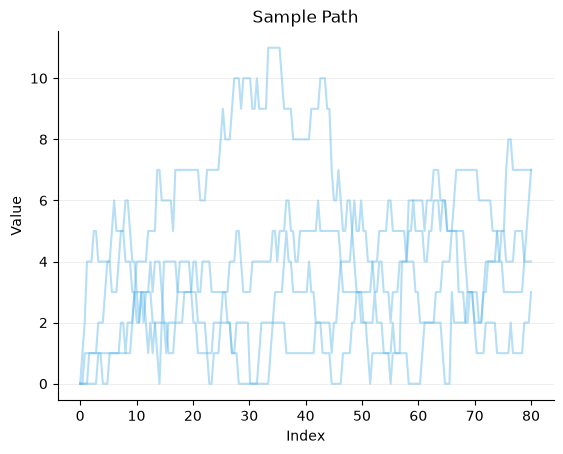

In [15]:
bank.sim(4).plot(tmin=0, tmax=80)

## What another server buys you

The same arrivals and the same service times, served by one, two, or three servers. One
server cannot keep up here (`utilization` above 1, so the line grows without bound); two
settle down; three barely let anybody wait.

1 server(s): utilization 1.250
2 server(s): utilization 0.625
3 server(s): utilization 0.417


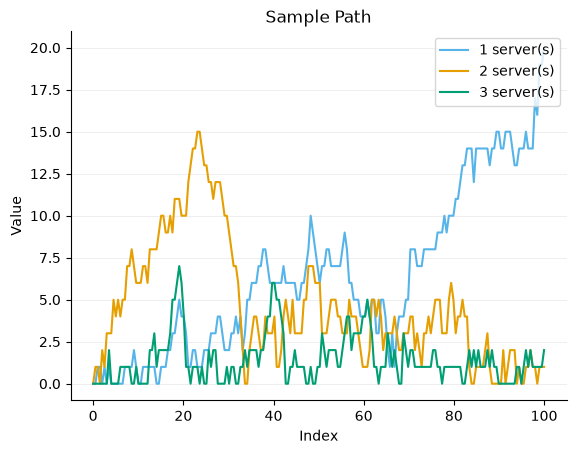

In [16]:
for servers in [1, 2, 3]:
    queue = GGs(Exponential(rate=1), Exponential(rate=0.8), servers=servers)
    print(f"{servers} server(s): utilization {queue.utilization:.3f}")
    # One path each, so the three are easy to tell apart.
    queue.sim(1).plot(tmin=0, tmax=100, label=f"{servers} server(s)")

## The number in the system at a fixed time

Index the queue at a time to get an ordinary random variable. With three tellers the bank
is rarely empty at this load, but it is rarely badly backed up either.

3.975

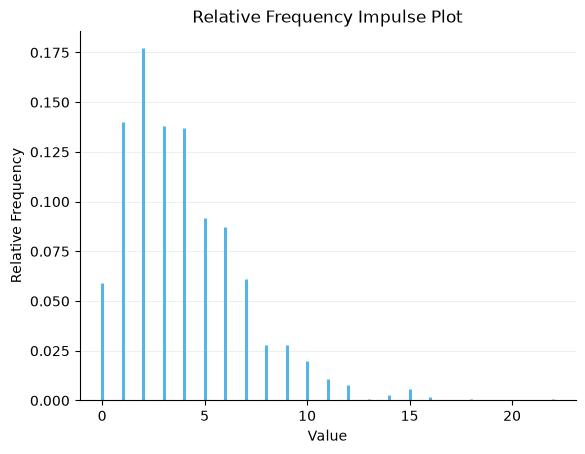

In [17]:
number = bank[50].sim(1000)
number.plot()
number.mean()

## The waits, and the line as opposed to the system

The path counts everybody in the system, including the ones being served. `get_number_waiting()`
counts only those still in line, and `waiting_times` gives each customer's own wait.

In [18]:
path = bank.draw()
print("in the system at t=40:", path(40.0))
print("still in line at t=40:", path.get_number_waiting()(40.0))
print("first five waits:", [round(path.waiting_times[n], 1) for n in range(5)])

in the system at t=40: 3
still in line at t=40: 0
first five waits: [0.0, 0.0, 0.0, 0.0, 0.0]


## The special case: M/M/s

Make both distributions exponential and you have an `M/M/s` queue -- Poisson arrivals,
exponential service. The `MMs` class in `markov_chains.py` models the same queue as a
birth-death Markov chain, which is only possible because the service times are exponential.

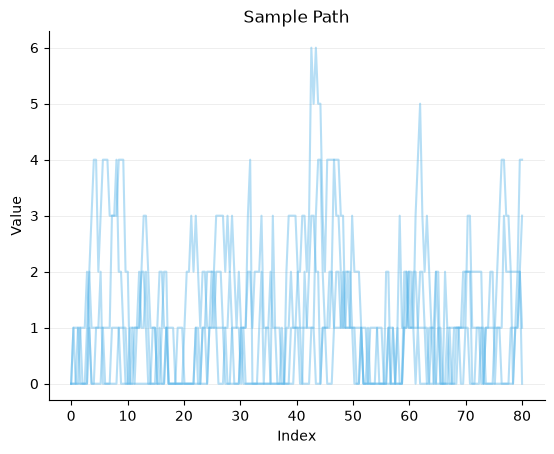

In [19]:
mms = GGs(Exponential(rate=1), Exponential(rate=1), servers=2)
mms.sim(4).plot(tmin=0, tmax=80)